In [7]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [8]:
torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device(type='cuda')

In [9]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.11.0+cu128
12.8
True


In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307),(0.1307))
])

In [11]:
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

In [12]:
train_dataset[0]

(tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.000

Label: 0


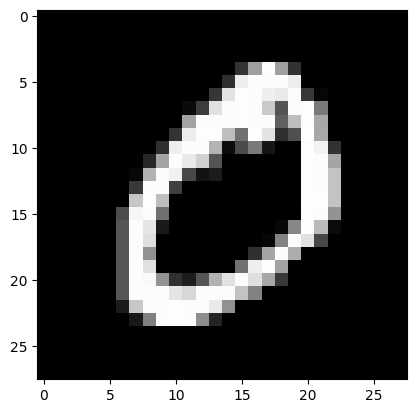

In [13]:
image, label = train_dataset[1]

plt.imshow(image.squeeze(), cmap='gray')
print(f"Label: {label}")

In [14]:
train_data = DataLoader(train_dataset, batch_size=64, shuffle= True)
test_data = DataLoader(test_dataset, batch_size=64, shuffle= False)

In [15]:
class MNISTModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear1 = torch.nn.Linear(784,256) # How was this calculated ? -> each image is 28x28 pixles results in 784 pixels in total
    self.linear2 = torch.nn.Linear(256, 128)
    self.linear3 = torch.nn.Linear(128, 64)
    self.linear4 = torch.nn.Linear(64, 10)

  def forward(self, x):
    x = x.view(-1, 784) # Flatten the image
    x = torch.relu(self.linear1(x))
    x = torch.relu(self.linear2(x))
    x = torch.relu(self.linear3(x))
    return self.linear4(x)


In [16]:
model = MNISTModel()

In [17]:
criterion = nn.CrossEntropyLoss()

In [18]:
adam_optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [19]:
epochs = 10

for epoch in range(epochs):
 for images, labels in train_data:
   adam_optimizer.zero_grad()
   outputs = model(images)
   loss = criterion(outputs, labels)
   loss.backward()
   adam_optimizer.step()
 print(f"Epoch: {epoch+1}, Loss: {loss.item():.4f}")

Epoch: 1, Loss: 0.2296
Epoch: 2, Loss: 0.1412
Epoch: 3, Loss: 0.1544
Epoch: 4, Loss: 0.0681
Epoch: 5, Loss: 0.0074
Epoch: 6, Loss: 0.0248
Epoch: 7, Loss: 0.0183
Epoch: 8, Loss: 0.0444
Epoch: 9, Loss: 0.0022
Epoch: 10, Loss: 0.0005


In [20]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_data:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 98.21%
